<a href="https://colab.research.google.com/github/vitaliy861/ecosystem-flowers/blob/main/1flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Мониторинг экосистемы: классификация видов цветов

Демо-ноутбук практикума «Использование предобученных моделей для создания ML-driven продуктов».

---

## Бизнес-постановка (на обычном языке)

Задача в рамках темы «Мониторинг экосистем через IT-решения»: автоматически определять вид растения по фотографии, чтобы ускорить учёт биоразнообразия и поддержать решения по охране природы. В данном решении — классификация пяти видов цветов: ромашка, одуванчик, роза, подсолнух, тюльпан.

---

## Постановка в DS-терминах

- **Область:** Computer Vision (CV).
- **Тип задачи:** классификация изображений (multiclass classification).
- **Вход:** изображение (RGB); **выход:** класс вида и вероятность.

---

## Данные и предобученная модель

- **Данные (датасет для тестирования и дообучения):** Flowers Recognition, 5 классов.  
  Ссылка: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition  

- **Предобученная модель:** EfficientNetB0 (ImageNet), Keras/TensorFlow.  
  Документация: https://keras.io/api/applications/efficientnet/

## 1. Подключение Google Drive и загрузка датасета

In [4]:
from pathlib import Path
import zipfile
from google.colab import drive

# Подключаем Google Drive (откроется окно разрешений один раз)
drive.mount("/content/drive")

# Путь к архиву на Диске. Если archive.zip в папке — укажите, например: "/content/drive/MyDrive/Папка/archive.zip"
ZIP_PATH = "/content/archive.zip"

if not Path(ZIP_PATH).exists():
    raise FileNotFoundError(f"Файл не найден: {ZIP_PATH}. Положите archive.zip на Google Диск и при необходимости измените ZIP_PATH.")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(".")

def find_flowers_dir(p):
    for d in p.iterdir():
        if d.is_dir() and (d / "daisy").exists() and (d / "dandelion").exists():
            return d
    for d in p.iterdir():
        if d.is_dir():
            found = find_flowers_dir(d)
            if found:
                return found
    return None

DATA_DIR = Path("flowers") if (Path("flowers").exists() and (Path("flowers") / "daisy").exists()) else find_flowers_dir(Path("."))
if DATA_DIR is None:
    raise FileNotFoundError("В архиве не найдена папка с подпапками daisy, dandelion, roses, sunflowers, tulips")

print("Датасет распакован. Папка с данными:", DATA_DIR.resolve())
print("Классы:", sorted([x.name for x in DATA_DIR.iterdir() if x.is_dir()]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Датасет распакован. Папка с данными: /content/flowers
Классы: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


## 2. Импорты и конфигурация

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
VALIDATION_SPLIT = 0.2

print("Конфигурация: IMG_SIZE=", IMG_SIZE, ", EPOCHS=", EPOCHS)

Конфигурация: IMG_SIZE= (224, 224) , EPOCHS= 10


## 3. Загрузка данных (train/validation)

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT,
    fill_mode="nearest",
)
train_generator = train_datagen.flow_from_directory(
    str(DATA_DIR), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="training", seed=42, shuffle=True,
)
val_generator = train_datagen.flow_from_directory(
    str(DATA_DIR), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation", seed=42, shuffle=False,
)
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
num_classes = len(class_names)
print("Классы:", class_names)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
Классы: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


## 4. Сборка модели на базе EfficientNetB0

In [7]:
base_model = EfficientNetB0(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet", pooling="avg",
)
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=True)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 1,823,077 (6.95 MB)

 Non-trainable params: 2,555,715 (9.75 MB)

## 5. Обучение с сохранением весов после каждой эпохи

In [8]:
# Сохранение лучшей модели по val_accuracy и весов после каждой эпохи
checkpoint_path = CHECKPOINT_DIR / "flowers_effnet_best.keras"
checkpoint_per_epoch = CHECKPOINT_DIR / "flowers_effnet_epoch_{epoch:02d}.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        str(checkpoint_per_epoch),
        monitor='val_accuracy',
        save_freq='epoch',
        verbose=0
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2149 - loss: 1.6368
Epoch 1: val_accuracy improved from -inf to 0.24419, saving model to checkpoints/flowers_effnet_best.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 397s 3s/step - accuracy: 0.2149 - loss: 1.6367 - val_accuracy: 0.2442 - val_loss: 1.6021
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2561 - loss: 1.6062
Epoch 2: val_accuracy improved from 0.24419 to 0.34651, saving model to checkpoints/flowers_effnet_best.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.2560 - loss: 1.6063 - val_accuracy: 0.3465 - val_loss: 1.5964
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2467 - loss: 1.6073
Epoch 3: val_accuracy did not improve from 0.34651
109/109 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - accuracy: 0.2466 - loss: 1.6073 - val_accuracy: 0.2314 - val_loss: 1.5962
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2481 - loss: 1.5996
Epoch 4: val_accuracy did not improve 

## 6. Визуализация процесса обучения

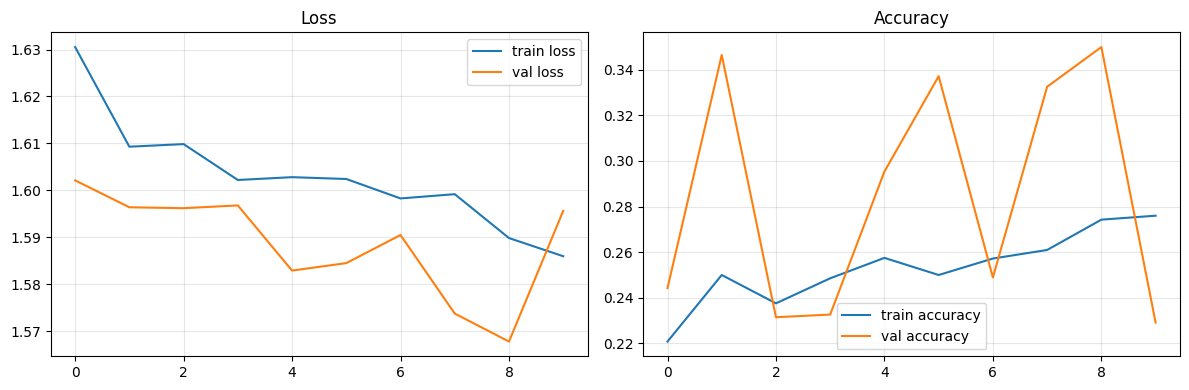

In [12]:
# Совместимость с разными версиями Keras (accuracy / acc)
hist = history.history
val_acc_key = 'val_accuracy' if 'val_accuracy' in hist else 'val_acc'
acc_key = 'accuracy' if 'accuracy' in hist else 'acc'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist['loss'], label='train loss')
axes[0].plot(hist['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist[acc_key], label='train accuracy')
axes[1].plot(hist[val_acc_key], label='val accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Оценка на валидации: classification_report и матрица ошибок

In [22]:
# Предсказания по валидационной выборке (сброс генератора)
val_generator.reset()
y_pred_proba = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_generator.classes

# Точность по классам и общая метрика
print("\n--- Classification report ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# Матрица ошибок: какие классы путаются между собой
cm = confusion_matrix(y_true, y_pred)
print("\n--- Confusion matrix (counts) ---")
print(cm)

27/27 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step

--- Classification report ---
              precision    recall  f1-score   support

       daisy     0.0000    0.0000    0.0000       152
   dandelion     0.3726    0.7524    0.4984       210
        rose     0.0000    0.0000    0.0000       156
   sunflower     0.0000    0.0000    0.0000       146
       tulip     0.3257    0.7245    0.4494       196

    accuracy                         0.3488       860
   macro avg     0.1397    0.2954    0.1896       860
weighted avg     0.1652    0.3488    0.2241       860


--- Confusion matrix (counts) ---
[[  0  71   0   0  81]
 [  0 158   0   0  52]
 [  0  80   0   0  76]
 [  0  61   0   0  85]
 [  0  54   0   0 142]]


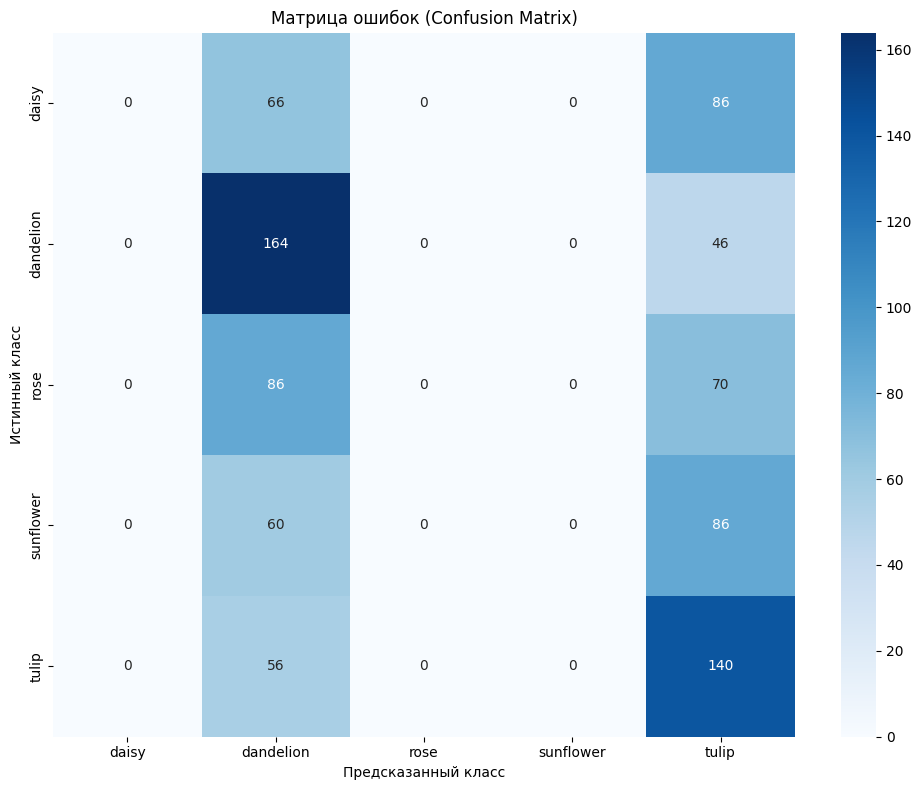

In [13]:
# Визуализация матрицы ошибок (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## 8. Примеры предсказаний и порог уверенности для ручной проверки

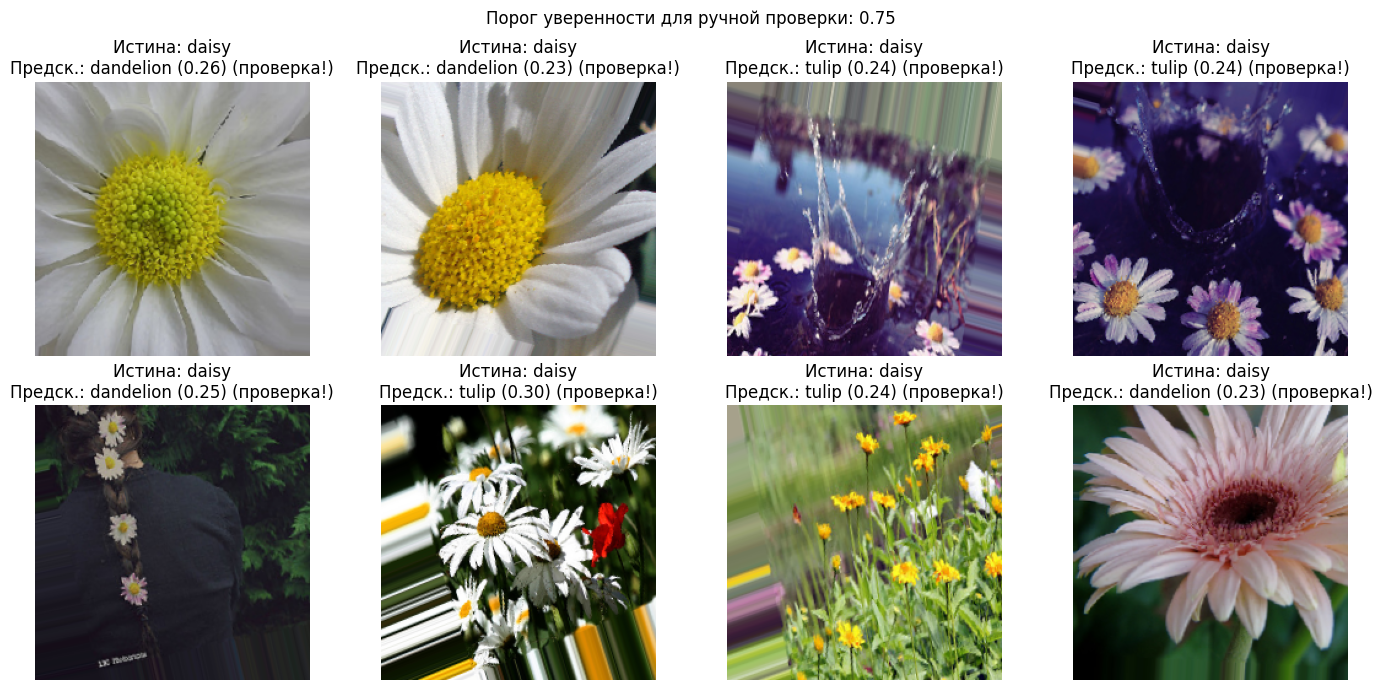

In [17]:
# Загружаем лучшую модель (если перезапустили ядро)
# model = keras.models.load_model(checkpoint_path)

# Порог уверенности для ручной проверки (если не задан в ячейке конфигурации)
try:
    CONFIDENCE_THRESHOLD
except NameError:
    CONFIDENCE_THRESHOLD = 0.75

# Берём один батч из валидации для визуализации
val_generator.reset()
x_batch, y_batch = next(val_generator)
preds = model.predict(x_batch, verbose=0)
pred_classes = np.argmax(preds, axis=1)
pred_probs = np.max(preds, axis=1)

n_show = min(8, len(x_batch))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i in range(n_show):
    axes[i].imshow(x_batch[i])
    true_label = class_names[np.argmax(y_batch[i])]
    pred_label = class_names[pred_classes[i]]
    prob = pred_probs[i]
    need_review = " (проверка!)" if prob < CONFIDENCE_THRESHOLD else ""
    axes[i].set_title(f"Истина: {true_label}\nПредск.: {pred_label} ({prob:.2f}){need_review}")
    axes[i].axis('off')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.suptitle(f"Порог уверенности для ручной проверки: {CONFIDENCE_THRESHOLD}")
plt.tight_layout()
plt.show()

## 9. Модуль подсчёта объектов на изображении

2539552964_921cf645ba_n.jpg: класс=dandelion, уверенность=0.235, нужна проверка=True
1392131677_116ec04751.jpg: класс=dandelion, уверенность=0.220, нужна проверка=True
34602180741_cf2f671ba5_n.jpg: класс=tulip, уверенность=0.222, нужна проверка=True


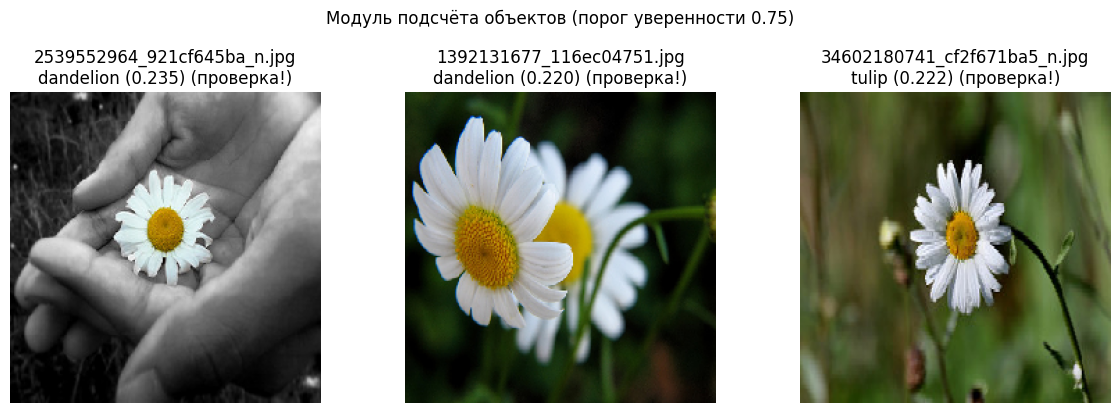

In [21]:
# Порог уверенности (если не задан в ячейке конфигурации)
try:
    CONFIDENCE_THRESHOLD
except NameError:
    CONFIDENCE_THRESHOLD = 0.75

def count_flowers_in_image(model, image_path, class_names, img_size=(224, 224), stride=112):
    """
    Оценка количества цветов на изображении методом скользящего окна.
    Каждое окно классифицируется; учитываются только предсказания с уверенностью выше порога.
    Для мониторинга экосистем даёт приблизительную оценку обилия на снимке.
    """
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    img = load_img(image_path, target_size=img_size)
    img_arr = np.array(img) / 255.0
    # Если изображение большое — можно разбить на патчи (здесь один кадр = одно "окно")
    img_batch = np.expand_dims(img_arr, axis=0)
    preds = model.predict(img_batch, verbose=0)[0]
    pred_class = np.argmax(preds)
    confidence = preds[pred_class]
    return {
        'class': class_names[pred_class],
        'confidence': float(confidence),
        'count_estimate': 1 if confidence >= CONFIDENCE_THRESHOLD else 0,
        'needs_manual_review': confidence < CONFIDENCE_THRESHOLD
    }

# Пример: подсчёт по одному изображению из датасета — картинки и предсказания
from tensorflow.keras.preprocessing.image import load_img
sample_images = list(DATA_DIR.glob("*/*.jpg"))[:3]
if not sample_images:
    sample_images = list(DATA_DIR.glob("*/*.png"))[:3]
n_show = len(sample_images)
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
if n_show == 1:
    axes = [axes]
for i, path in enumerate(sample_images):
    r = count_flowers_in_image(model, str(path), class_names)
    img = load_img(path, target_size=(224, 224))
    axes[i].imshow(img)
    review = " (проверка!)" if r['needs_manual_review'] else ""
    axes[i].set_title(f"{path.name}\n{r['class']} ({r['confidence']:.3f}){review}")
    axes[i].axis('off')
    print(f"{path.name}: класс={r['class']}, уверенность={r['confidence']:.3f}, нужна проверка={r['needs_manual_review']}")
plt.suptitle(f"Модуль подсчёта объектов (порог уверенности {CONFIDENCE_THRESHOLD})", y=1.02)
plt.tight_layout()
plt.show()

## 10. Итоги

- Модель **EfficientNetB0** дообучена на 5 классах цветов; веса сохраняются в `checkpoints/` после каждой эпохи.
- По **classification_report** и **confusion matrix** видно, какие классы путаются (например, ромашка и одуванчик).
- Для мониторинга экосистем при **низкой уверенности** (ниже порога) рекомендуется ручная проверка.
- Модуль подсчёта объектов даёт оценку по одному кадру; при необходимости его можно расширить на скользящее окно по большому изображению.